In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import scipy as sp
import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.colorbar as clb
from matplotlib import gridspec
from matplotlib.patches import Rectangle

import pickle

In [2]:
def calc_rmse(model1, model2):
    return np.sqrt(np.linalg.norm(model1 - model2, ord=2)**2 / len(model1))

### Model domain

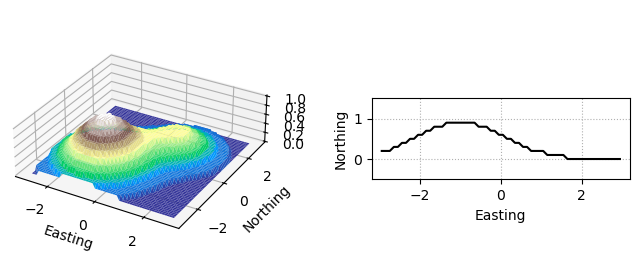

In [3]:
### Creation of subsurface grid: xgrd, ygrd, zgrd ###
# incx, incy, incz : grid spacing in the x, y, and z directions
incx = 0.1
incy = 0.1
incz = 0.1

x = np.arange(-3.0 + 0.5*incx, 3.0, incx)
y = np.arange(-3.0 + 0.5*incy, 3.0, incy)
nx = len(x)
ny = len(y)

# Two hills (northeast and southwest)
from scipy.ndimage import gaussian_filter

X, Y = np.meshgrid(x, y)

# Northeast hill
A1 = 0.5
x1, y1 = 1.0, 1.0
sigma1 = 1.25
z1 = A1 * np.exp(-((X - x1)**2 + (Y - y1)**2) / sigma1**2)

# Southwest hill
A2 = 1.0
x2, y2 = -1.0, -1.0
sigma2 = 1.5
z2 = A2 * np.exp(-((X - x2)**2 + (Y - y2)**2) / sigma2**2)

# Combined topography
T = z1 + z2

# Round to 0.1 increments
T = np.round(T / 0.1) * 0.1

### Creation of subsurface grid: xgrd, ygrd, zgrd ###
# Number of subsurface layers = 30  # 60×60×30
nz = 30
[yy2, zz2, xx2] = np.meshgrid(y, np.zeros(nz), x)

for k in range(nz):
    for i in range(nx):
        for j in range(ny):
            zz2[k, j, i] = T.reshape(-1)[i + nx*j] - incz / 2. - incz*k
            
xgrd = xx2.reshape(-1)
ygrd = yy2.reshape(-1)
zgrd = zz2.reshape(-1)

# For visualization
xfig, yfig, zfig = [], [], []

for i in range(len(xgrd)):
    j = i // (nx*ny)
    
    # Store coordinates of the 8 vertices of each grid cell
    xfig.append([xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx, xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx, 
                 xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx, xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx])
    yfig.append([ygrd[i] - 0.5*incy, ygrd[i] - 0.5*incy, ygrd[i] + 0.5*incy, ygrd[i] + 0.5*incy, 
                 ygrd[i] - 0.5*incy, ygrd[i] - 0.5*incy, ygrd[i] + 0.5*incy, ygrd[i] + 0.5*incy])
    zfig.append([zgrd[i] - 0.5*incz, zgrd[i] - 0.5*incz, zgrd[i] - 0.5*incz, zgrd[i] - 0.5*incz, 
                 zgrd[i] + 0.5*incz, zgrd[i] + 0.5*incz, zgrd[i] + 0.5*incz, zgrd[i] + 0.5*incz])

# Convert to arrays
xfig = np.array(xfig)
yfig = np.array(yfig)
zfig = np.array(zfig)

# dim: block size
dim = [[incx / 2., incx / 2.], [incy / 2., incy / 2.], [incz / 2., incz / 2.]]

# Near Tokyo
# Declination (degrees)
dec = -7.
# Inclination (degrees)
inc = 50.

# Visualization
fig = plt.figure(figsize = (8, 4))
plt.subplots_adjust(wspace=0.4, hspace=0.)

ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(X, Y, T, rstride=1, cstride=1, cmap = plt.cm.terrain)
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
ax.set_box_aspect((1,1,0.3))

ax = fig.add_subplot(122)
ys = 15
ax.plot(X[ys, :], T[ys,:], color = "black")
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
ax.set_aspect("equal")
ax.set_xlim(-3.2, 3.2)
ax.set_ylim(-0.5, 1.5)
ax.grid(linestyle = "dotted")

### Input models

In [4]:
### Magnetization structure  ###

# Spherical demagnetized source  
zcenter = -0.5
a_rad = 0.5
b_rad = 0.5
c_rad = 0.5

# Lateral dike intrusion
# Direction vector (NE + 30° up)
d = np.array([
    np.cos(np.deg2rad(10)) / np.sqrt(2),
    np.cos(np.deg2rad(10)) / np.sqrt(2),
    np.sin(np.deg2rad(10))
])  # normalized

# Center
center = np.array([-0.95, -0.95, -0.2])

# Dike radius
dike_r = 0.1

# Vector from grid points to the dike origin
dx = xx2 - center[0]
dy = yy2 - center[1]
dz = zz2 - center[2]

# Distance along the axis t (projection)
t = dx * d[0] + dy * d[1] + dz * d[2]

# Distance from the axis
px = center[0] + t * d[0]
py = center[1] + t * d[1]
pz = center[2] + t * d[2]

dist_axis = np.sqrt((xx2 - px)**2 + (yy2 - py)**2 + (zz2 - pz)**2)

# ------------------------------------------------------------ #
### Time1 ###
beta1 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if (xgrd[k] - center[0])**2 / a_rad**2 + (ygrd[k] - center[1])**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta1[k] = -5

# Dike 1
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if ((xgrd[k] - center[0])**2 + (ygrd[k] - center[1])**2 <= 0.15**2) & (0.2 <= zgrd[k]) & (zgrd[k] <= 0.8):
                beta1[k] = -4

### Time2 ###
beta2 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if (xgrd[k] - center[0])**2 / a_rad**2 + (ygrd[k] - center[1])**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta2[k] = -5
                
# Dike 1
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if ((xgrd[k] - center[0])**2 + (ygrd[k] - center[1])**2 <= 0.15**2) & (0.2 <= zgrd[k]) & (zgrd[k] <= 0.8):
                beta2[k] = -2
                
### Time3 ###
beta3 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if (xgrd[k] - center[0])**2 / a_rad**2 + (ygrd[k] - center[1])**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta3[k] = -5

# Dike 1
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if ((xgrd[k] - center[0])**2 + (ygrd[k] - center[1])**2 <= 0.15**2) & (0.2 <= zgrd[k]) & (zgrd[k] <= 0.8):
                beta3[k] = 1

# Dike 2
L3 = 2.6 # Dike length
inside_dike = (dist_axis <= dike_r) & (t >= 0) & (t <= L3)
beta3.reshape(xx2.shape)[inside_dike] = -5

### Time4 ###
beta4 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if (xgrd[k] - center[0])**2 / a_rad**2 + (ygrd[k] - center[1])**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta4[k] = -5

# Dike 1
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if ((xgrd[k] + - center[0])**2 + (ygrd[k] - center[1])**2 <= 0.15**2) & (0.2 <= zgrd[k]) & (zgrd[k] <= 0.8):
                beta4[k] = 5

# Dike 2
L4 = 2.6 # Dike length
inside_dike = (dist_axis <= dike_r) & (t >= 0) & (t <= L4)
beta4.reshape(xx2.shape)[inside_dike] = -5

bb1 = beta1.reshape(nz, ny, nx)
bb2 = beta2.reshape(nz, ny, nx)
bb3 = beta3.reshape(nz, ny, nx)
bb4 = beta4.reshape(nz, ny, nx)

### Estimated models

#### Parallel Inversion

In [5]:
# Read
with open('models/Params_case_2_1_parallel.pickle', 'rb') as f:
    params_par = pickle.load(f)
with open('models/Betas1_case_2_1_parallel.pickle', 'rb') as f:
    betas1_par = pickle.load(f)
with open('models/Betas2_case_2_1_parallel.pickle', 'rb') as f:
    betas2_par = pickle.load(f)
with open('models/Betas3_case_2_1_parallel.pickle', 'rb') as f:
    betas3_par = pickle.load(f)
with open('models/Betas4_case_2_1_parallel.pickle', 'rb') as f:
    betas4_par = pickle.load(f)

# optimal parameters  # estimated by L-curve  # For more details, refer to the executable file
num_opt_1_par, num_opt_2_par, num_opt_3_par, num_opt_4_par = 5, 5, 5, 5
print("optimal λ = {:.2f}, {:.2f}, {:.2f}, {:.2f}".format(params_par[num_opt_1_par], 
                                                          params_par[num_opt_2_par], 
                                                          params_par[num_opt_3_par], 
                                                          params_par[num_opt_4_par])
     )

# optimal models
beta1_par_temp = betas1_par[num_opt_1_par]
beta2_par_temp = betas2_par[num_opt_2_par]
beta3_par_temp = betas3_par[num_opt_3_par]
beta4_par_temp = betas4_par[num_opt_4_par]

optimal λ = 17.78, 17.78, 17.78, 17.78


#### Differential Inversion

In [6]:
# Read
with open('models/Params_case_2_1_differential.pickle', 'rb') as f:
    params_dif = pickle.load(f)
with open('models/Betas_del12_case_2_1_differential.pickle', 'rb') as f:
    betas_del12_dif = pickle.load(f)
with open('models/Betas_del23_case_2_1_differential.pickle', 'rb') as f:
    betas_del23_dif = pickle.load(f)
with open('models/Betas_del34_case_2_1_differential.pickle', 'rb') as f:
    betas_del34_dif = pickle.load(f)
    
# optimal parameter  # estimated by L-curve  # For more details, refer to the executable file
num_opt_1_dif, num_opt_2_dif, num_opt_3_dif = 6, 6, 6
print("optimal λ = {:.2f}, {:.2f}, {:.2f}".format(params_dif[num_opt_1_dif],
                                                  params_dif[num_opt_2_dif],
                                                  params_dif[num_opt_3_dif],)
     )

# optimal model
beta_del12_dif_temp = betas_del12_dif[num_opt_1_dif]
beta_del23_dif_temp = betas_del23_dif[num_opt_2_dif]
beta_del34_dif_temp = betas_del34_dif[num_opt_3_dif]

beta2_dif_temp = beta1_par_temp + beta_del12_dif_temp
beta3_dif_temp = beta2_dif_temp + beta_del23_dif_temp
beta4_dif_temp = beta3_dif_temp + beta_del34_dif_temp

optimal λ = 31.62, 31.62, 31.62


#### SC-TLI

In [7]:
# Read
with open('models/Params_case_2_1_new_4d-3.pickle', 'rb') as f:
    params_4d = pickle.load(f)
with open('models/Betas1_case_2_1_new_4d-3.pickle', 'rb') as f:
    betas1_4d = pickle.load(f)
with open('models/Betas2_case_2_1_new_4d-3.pickle', 'rb') as f:
    betas2_4d = pickle.load(f)
with open('models/Betas3_case_2_1_new_4d-3.pickle', 'rb') as f:
    betas3_4d = pickle.load(f)
with open('models/Betas4_case_2_1_new_4d-3.pickle', 'rb') as f:
    betas4_4d = pickle.load(f)

# optimal parameter  # estimated by L-curve  # For more details, refer to the executable file
num_opt_4d = 5
print("Optimal λs = {:2f}, λt = {}".format(params_4d[num_opt_4d][0], params_4d[num_opt_4d][1]))

# optimal models
beta1_4d_temp = betas1_4d[num_opt_4d]
beta2_4d_temp = betas2_4d[num_opt_4d]
beta3_4d_temp = betas3_4d[num_opt_4d]
beta4_4d_temp = betas4_4d[num_opt_4d]

Optimal λs = 17.782794, λt = 100.0


#### RMSE for temporal changes

In [8]:
# Table 3
columns = pd.MultiIndex.from_tuples([
    ("", "Par."), ("T2 - T1", "Diff."), ("", "SC-TLI"),
    ("", "Par."), ("T3 - T2", "Diff."), ("", "SC-TLI"),
    ("", "Par."), ("T4 - T3", "Diff."), ("", "SC-TLI"),
])

data_var = [["{:.4f}".format(calc_rmse(beta2 - beta1, beta2_par_temp - beta1_par_temp)), 
             "{:.4f}".format(calc_rmse(beta2 - beta1, beta2_dif_temp - beta1_par_temp)), 
             "{:.4f}".format(calc_rmse(beta2 - beta1, beta2_4d_temp  - beta1_4d_temp)), 
             "{:.4f}".format(calc_rmse(beta3 - beta2, beta3_par_temp - beta2_par_temp)), 
             "{:.4f}".format(calc_rmse(beta3 - beta2, beta3_dif_temp - beta2_dif_temp)),
             "{:.4f}".format(calc_rmse(beta3 - beta2, beta3_4d_temp  - beta2_4d_temp)), 
             "{:.4f}".format(calc_rmse(beta4 - beta3, beta4_par_temp - beta3_par_temp)), 
             "{:.4f}".format(calc_rmse(beta4 - beta3, beta4_dif_temp - beta3_dif_temp)), 
             "{:.4f}".format(calc_rmse(beta4 - beta3, beta4_4d_temp -  beta3_4d_temp))],
]
index = ["Case 2-1"]

df_var = pd.DataFrame(data_var, index=index, columns=columns)
df_var

T2 - T1                 T3 - T2                 T4 - T3  \
            Par.   Diff.  SC-TLI    Par.   Diff.  SC-TLI    Par.   Diff.   
Case 2-1  0.0352  0.0243  0.0275  0.1390  0.1283  0.1232  0.0890  0.0513   

                  
          SC-TLI  
Case 2-1  0.0584

#### RMSE for each model

In [9]:
# Table 4
columns = pd.MultiIndex.from_tuples([
    ("", "Par."), ("T1", "Diff."), ("", "SC-TLI"),
    ("", "Par."), ("T2", "Diff."), ("", "SC-TLI"),
    ("", "Par."), ("T3", "Diff."), ("", "SC-TLI"),
    ("", "Par."), ("T4", "Diff."), ("", "SC-TLI"),
])

data = [["{:.3f}".format(calc_rmse(beta1, beta1_par_temp)), 
         "{:.3f}".format(calc_rmse(beta1, beta1_par_temp)), 
         "{:.3f}".format(calc_rmse(beta1, beta1_4d_temp)), 
         "{:.3f}".format(calc_rmse(beta2, beta2_par_temp)), 
         "{:.3f}".format(calc_rmse(beta2, beta2_dif_temp)), 
         "{:.3f}".format(calc_rmse(beta2, beta2_4d_temp)), 
         "{:.3f}".format(calc_rmse(beta3, beta3_par_temp)), 
         "{:.3f}".format(calc_rmse(beta3, beta3_dif_temp)), 
         "{:.3f}".format(calc_rmse(beta3, beta3_4d_temp)),
         "{:.3f}".format(calc_rmse(beta4, beta4_par_temp)), 
         "{:.3f}".format(calc_rmse(beta4, beta4_dif_temp)), 
         "{:.3f}".format(calc_rmse(beta4, beta4_4d_temp))],
]
index = ["Case 2-1"]

df = pd.DataFrame(data, index=index, columns=columns)
df

T1                   T2                   T3         \
           Par.  Diff. SC-TLI   Par.  Diff. SC-TLI   Par.  Diff. SC-TLI   
Case 2-1  0.178  0.178  0.182  0.174  0.173  0.177  0.217  0.209  0.208   

                    T4         
           Par.  Diff. SC-TLI  
Case 2-1  0.260  0.219  0.220

### Figure 12

In [ ]:
# Colormap
cmap = cm.get_cmap("RdBu")
norm = Normalize(vmin = -6, vmax = 6)

# Figure setup
fig = plt.figure(figsize = (14, 10))
plt.subplots_adjust(wspace=0.1, hspace=-0.45)

#--- Input models ---#

# T2 - T1
ax = fig.add_subplot(441)

# Cross-section (NE-SW)
for i in range(len(xgrd)):

    # Eight vertices of each voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE-SW cross-section condition: y ≈ x ---
    # Center of the voxel
    xc = xgrd[i]
    yc = ygrd[i]
    
    tol = 0.05   # Cross-sectional width (adjust as needed)
    if abs(yc - xc) < tol:

        # Distance axis along the cross-section direction (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color according to the value of beta_forward
        beta_val = (beta2 - beta1)[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (without interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
#ax.set_xlabel("Easting (km)")
ax.set_ylabel("Altitude (km)")
#ax.set_title("$T_2 - T_1$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelbottom=False)
ax.tick_params(width = 1, length = 1)

#ax.text(-0.35, 0.5, "Input models", fontsize=14,
#        rotation=90, va='center', ha='center',
#        transform=ax.transAxes)

# T3 - T2
ax = fig.add_subplot(442)

# Cross-section (NE-SW)
for i in range(len(xgrd)):

    # Eight vertices of each voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE-SW cross-section condition: y ≈ x ---
    # Center of the voxel
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the cross-section direction (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color according to the value of beta_forward
        beta_val = (beta3 - beta2)[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (without interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
#ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T_3 - T_2$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, labelbottom=False)
ax.tick_params(width = 1, length = 1)

# T4 - T3
ax = fig.add_subplot(443)

# Cross-section (NE-SW)
for i in range(len(xgrd)):

    # Eight vertices of each voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE-SW cross-section condition: y ≈ x ---
    # Center of the voxel
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the cross-section direction (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color according to the value of beta_forward
        beta_val = (beta4 - beta3)[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (without interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
#ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T_4 - T_3$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, labelbottom=False)
ax.tick_params(width = 1, length = 1)


#--- Parallel inversion ---#

# T2 - T1
ax = fig.add_subplot(445)

# Cross-section (NE-SW)
for i in range(len(xgrd)):

    # Eight vertices of each voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE-SW cross-section condition: y ≈ x ---
    # Center of the voxel
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the cross-section direction (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color according to the value of beta_forward
        beta_val = (beta2_par_temp - beta1_par_temp)[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (without interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
#ax.set_xlabel("Easting (km)")
ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_1$")
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelbottom=False)
ax.tick_params(width = 1, length = 1)

#ax.text(-0.35, 0.5, "Parallel inv.", fontsize=14,
#rotation=90, va='center', ha='center',
#        transform=ax.transAxes)

# T3 - T2
ax = fig.add_subplot(446)

# Cross-section (NE-SW)
for i in range(len(xgrd)):

    # Eight vertices of each voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE-SW cross-section condition: y ≈ x ---
    # Center of the voxel
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the cross-section direction (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color according to the value of beta_forward
        beta_val = (beta3_par_temp - beta2_par_temp)[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (without interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
#ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_2$")
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, labelbottom=False)
ax.tick_params(width = 1, length = 1)

# T4 - T3
ax = fig.add_subplot(447)

# Cross-section (NE-SW)
for i in range(len(xgrd)):

    # Eight vertices of each voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE-SW cross-section condition: y ≈ x ---
    # Center of the voxel
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the cross-section direction (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color according to the value of beta_forward
        beta_val = (beta4_par_temp - beta3_par_temp)[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (without interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
#ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_3$")
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, labelbottom=False)
ax.tick_params(width = 1, length = 1)


#--- Differential inversion ---#

# T2 - T1
ax = fig.add_subplot(449)

# Cross-section (NE-SW)
for i in range(len(xgrd)):

    # Eight vertices of each voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE-SW cross-section condition: y ≈ x ---
    # Center of the voxel
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the cross-section direction (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color according to the value of beta_forward
        beta_val = beta_del12_dif_temp[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (without interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
#ax.set_xlabel("Easting (km)")
ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_1$")
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelbottom=False)
ax.tick_params(width = 1, length = 1)

#ax.text(-0.35, 0.5, "Differential inv.", fontsize=14,
#        rotation=90, va='center', ha='center',
#        transform=ax.transAxes)

# T3 - T2
ax = fig.add_subplot(4,4,10)

# Cross-section (NE-SW)
for i in range(len(xgrd)):

    # Eight vertices of each voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE-SW cross-section condition: y ≈ x ---
    # Center of the voxel
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the cross-section direction (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color according to the value of beta_forward
        beta_val = beta_del23_dif_temp[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (without interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
       
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
#ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_2$")
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, labelbottom=False)
ax.tick_params(width = 1, length = 1)

# T4 - T3
ax = fig.add_subplot(4,4,11)

# Cross-section (NE-SW)
for i in range(len(xgrd)):

    # Eight vertices of each voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE-SW cross-section condition: y ≈ x ---
    # Center of the voxel
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the cross-section direction (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color according to the value of beta_forward
        beta_val = beta_del34_dif_temp[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (without interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
#ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_3$")
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, labelbottom=False)
ax.tick_params(width = 1, length = 1)


#--- 4D inversion ---#

# T2 - T1
ax = fig.add_subplot(4,4,13)

# Cross-section (NE-SW)
for i in range(len(xgrd)):

    # Eight vertices of each voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE-SW cross-section condition: y ≈ x ---
    # Center of the voxel
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the cross-section direction (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color according to the value of beta_forward
        beta_val = (beta2_4d_temp - beta1_4d_temp)[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (without interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
ax.set_xlabel("Easting (km)")
ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_1$")
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(width = 1, length = 1)

#ax.text(-0.35, 0.5, "4D inv.", fontsize=14,
#        rotation=90, va='center', ha='center',
#        transform=ax.transAxes)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])
cax = inset_axes(ax,
                 width="85%",
                 height="10%",
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1),
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal", cmap = "bwr_r")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization change (A/m)", fontsize = 12)

# T3 - T2
ax = fig.add_subplot(4,4,14)

# Cross-section (NE-SW)
for i in range(len(xgrd)):

    # Eight vertices of each voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE-SW cross-section condition: y ≈ x ---
    # Center of the voxel
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the cross-section direction (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color according to the value of beta_forward
        beta_val = (beta3_4d_temp - beta2_4d_temp)[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (without interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_2$")
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False)
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
cax = inset_axes(ax,
                 width="85%",
                 height="10%",
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1),
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal", cmap = "bwr_r")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization change (A/m)", fontsize = 12)

# T4 - T3
ax = fig.add_subplot(4,4,15)

# Cross-section (NE-SW)
for i in range(len(xgrd)):

    # Eight vertices of each voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE-SW cross-section condition: y ≈ x ---
    # Center of the voxel
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the cross-section direction (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color according to the value of beta_forward
        beta_val = (beta4_4d_temp - beta3_4d_temp)[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (without interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_3$")
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False)
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal", cmap = "bwr_r")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization change (A/m)", fontsize = 12)

plt.savefig("Figure12.svg", dpi = 600, transparent = True)

C:\Users\ri710\AppData\Local\Temp\ipykernel_39976\2207277709.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("RdBu")


### Figure 16

In [ ]:
# Colormap
from matplotlib import cm
cmap = cm.get_cmap("RdYlBu")
norm = Normalize(vmin = -6, vmax = 6)

# Plotting
fig = plt.figure(figsize = (14, 10))
plt.subplots_adjust(wspace=0.1, hspace=-0.45)

#--- Input model ---#

# T = T1
ax = fig.add_subplot(441)

# Cross-section (NE-SW)
for i in range(len(xgrd)):

    # Eight vertices of each voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE-SW cross-section condition: y ≈ x ---
    # Center of the voxel
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the cross-section direction (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color based on the value of beta_forward
        beta_val = beta1[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (without interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
#ax.set_xlabel("Distance along NE–SW (km)")
ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_1$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelbottom=False)
ax.tick_params(width = 1, length = 1)

# T = T2
ax = fig.add_subplot(442)

# Cross-section (NE-SW)
for i in range(len(xgrd)):

    # Eight vertices of each voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE-SW cross-section condition: y ≈ x ---
    # Center of the voxel
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the cross-section direction (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color based on the value of beta_forward
        beta_val = beta2[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (without interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
#ax.set_xlabel("Distance along NE–SW (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_1$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, labelbottom=False)
ax.tick_params(width = 1, length = 1)

# T = T3
ax = fig.add_subplot(443)

# Cross-section (NE-SW)
for i in range(len(xgrd)):

    # Eight vertices of each voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE-SW cross-section condition: y ≈ x ---
    # Center of the voxel
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the cross-section direction (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color based on the value of beta_forward
        beta_val = beta3[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (without interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
#ax.set_xlabel("Distance along NE–SW (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_1$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, labelbottom=False)
ax.tick_params(width = 1, length = 1)

# T = T4
ax = fig.add_subplot(444)

# Cross-section (NE-SW)
for i in range(len(xgrd)):

    # Eight vertices of each voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE-SW cross-section condition: y ≈ x ---
    # Center of the voxel
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the cross-section direction (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color based on the value of beta_forward
        beta_val = beta4[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (without interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
#ax.set_xlabel("Distance along NE–SW (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_1$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, labelbottom=False)
ax.tick_params(width = 1, length = 1)


#--- Parallel inversion ---#

# T = T1
ax = fig.add_subplot(445)

# Cross-section (NE-SW)
for i in range(len(xgrd)):

    # Eight vertices of each voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE-SW cross-section condition: y ≈ x ---
    # Center of the voxel
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the cross-section direction (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color based on the value of beta_forward
        beta_val = beta1_par_temp[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (without interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
#ax.set_xlabel("Distance along NE–SW (km)")
ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_1$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelbottom=False)
ax.tick_params(width = 1, length = 1)

# T = T2
ax = fig.add_subplot(446)

# Cross-section (NE-SW)
for i in range(len(xgrd)):

    # Eight vertices of each voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE-SW cross-section condition: y ≈ x ---
    # Center of the voxel
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the cross-section direction (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color based on the value of beta_forward
        beta_val = beta2_par_temp[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (without interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
#ax.set_xlabel("Distance along NE–SW (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_1$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, labelbottom=False)
ax.tick_params(width = 1, length = 1)

# T = T3
ax = fig.add_subplot(447)

# Cross-section (NE-SW)
for i in range(len(xgrd)):

    # Eight vertices of each voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE-SW cross-section condition: y ≈ x ---
    # Center of the voxel
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the cross-section direction (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color based on the value of beta_forward
        beta_val = beta3_par_temp[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (without interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
#ax.set_xlabel("Distance along NE–SW (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_1$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, labelbottom=False)
ax.tick_params(width = 1, length = 1)

# T = T4
ax = fig.add_subplot(448)

# Cross-section (NE-SW)
for i in range(len(xgrd)):

    # Eight vertices of each voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE-SW cross-section condition: y ≈ x ---
    # Center of the voxel
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the cross-section direction (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color based on the value of beta_forward
        beta_val = beta4_par_temp[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (without interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
#ax.set_xlabel("Distance along NE–SW (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_1$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, labelbottom=False)
ax.tick_params(width = 1, length = 1)


#--- Differential inversion ---#

# T = T1
ax = fig.add_subplot(449)

# Cross-section (NE-SW)
for i in range(len(xgrd)):

    # Eight vertices of each voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE-SW cross-section condition: y ≈ x ---
    # Center of the voxel
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the cross-section direction (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color based on the value of beta_forward
        beta_val = beta1_par_temp[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (without interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
#ax.set_xlabel("Distance along NE–SW (km)")
ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_1$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelbottom=False)
ax.tick_params(width = 1, length = 1)

# T = T2
ax = fig.add_subplot(4,4,10)

# Cross-section (NE-SW)
for i in range(len(xgrd)):

    # Eight vertices of each voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE-SW cross-section condition: y ≈ x ---
    # Center of the voxel
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the cross-section direction (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color based on the value of beta_forward
        beta_val = beta2_dif_temp[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (without interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
#ax.set_xlabel("Distance along NE–SW (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_1$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, labelbottom=False)
ax.tick_params(width = 1, length = 1)

# T = T3
ax = fig.add_subplot(4,4,11)

# Cross-section (NE-SW)
for i in range(len(xgrd)):

    # Eight vertices of each voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE-SW cross-section condition: y ≈ x ---
    # Center of the voxel
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the cross-section direction (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color based on the value of beta_forward
        beta_val = beta3_dif_temp[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (without interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
#ax.set_xlabel("Distance along NE–SW (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_1$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, labelbottom=False)
ax.tick_params(width = 1, length = 1)

# T = T4
ax = fig.add_subplot(4,4,12)

# Cross-section (NE-SW)
for i in range(len(xgrd)):

    # Eight vertices of each voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE-SW cross-section condition: y ≈ x ---
    # Center of the voxel
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the cross-section direction (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color based on the value of beta_forward
        beta_val = beta4_dif_temp[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (without interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
#ax.set_xlabel("Distance along NE–SW (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_1$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, labelbottom=False)
ax.tick_params(width = 1, length = 1)


#--- 4D inversion ---#

# T = T1
ax = fig.add_subplot(4,4,13)

# Cross-section (NE-SW)
for i in range(len(xgrd)):

    # Eight vertices of each voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE-SW cross-section condition: y ≈ x ---
    # Center of the voxel
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the cross-section direction (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color based on the value of beta_forward
        beta_val = beta1_4d_temp[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (without interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
ax.set_xlabel("Distance along NE–SW (km)")
ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_1$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization (A/m)", fontsize = 12)

# T = T2
ax = fig.add_subplot(4,4,14)

# Cross-section (NE-SW)
for i in range(len(xgrd)):

    # Eight vertices of each voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE-SW cross-section condition: y ≈ x ---
    # Center of the voxel
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the cross-section direction (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color based on the value of beta_forward
        beta_val = beta2_4d_temp[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (without interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
ax.set_xlabel("Distance along NE–SW (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_1$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False)
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization (A/m)", fontsize = 12)

# T = T3
ax = fig.add_subplot(4,4,15)

# Cross-section (NE-SW)
for i in range(len(xgrd)):

    # Eight vertices of each voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE-SW cross-section condition: y ≈ x ---
    # Center of the voxel
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the cross-section direction (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color based on the value of beta_forward
        beta_val = beta3_4d_temp[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (without interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
ax.set_xlabel("Distance along NE–SW (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_1$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False)
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization (A/m)", fontsize = 12)

# T = T4
ax = fig.add_subplot(4,4,16)

# Cross-section (NE-SW)
for i in range(len(xgrd)):

    # Eight vertices of each voxel
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE-SW cross-section condition: y ≈ x ---
    # Center of the voxel
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # Distance axis along the cross-section direction (SW → NE)
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # Get color based on the value of beta_forward
        beta_val = beta4_4d_temp[i]
        color = cmap(norm(beta_val))
        
        # Draw rectangle (without interpolation)
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
ax.set_xlabel("Distance along NE–SW (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_1$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False)
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
cax = inset_axes(ax,
                 width="85%",
                 height="10%",
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1), 
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization (A/m)", fontsize = 12)

plt.savefig("Figure16.svg", dpi = 600, transparent = True)